![Práctica 5 - Librería SCIKIT-LEARN](img/cabecera-Scikit-learn.png)

Resuelto por: 

- Adrián Benítez Roldán
- Alejandro Montes Cantero

# Scikit-learn (parte 1).

**`Scikit-learn`** es un conjunto de librerias para **aprendizaje automático** en Python, que contiene multitud de herramientas para análisis y minería de datos. Está construida sobre Numpy, Scipy y Matplotlib.

## Introducción.

De forma muy genérica, el aprendizaje automático consiste en predecir propiedades de un objeto o dato desconocido a partir de sus propiedades y de las propiedades de un grupo de ejemplos. De cada ejemplo se suele disponer de un gran número de características sobre las que se trabaja.

El aprendizaje puede ser de dos formas:

* **Supervisado**, en el que los ejemplos disponen de la propiedad que queremos adivinar. Algunos ejemplos son la clasificación o la regresión.
* **No supervisado**, en la que los ejemplos de entrenamiento no tienen la característica que queremos predecir, como por ejemplo, el *clustering* (agrupar elementos parecidos) o la reducción de la dimensionalidad (reducir el número de características a otras mas representativas).

![scikit-learn algorithm cheat sheet](http://scikit-learn.org/dev/_static/ml_map.png)


## Conjuntos de datos.

Para realizar el aprendizaje se suelen utilizar dos conjuntos de datos: los datos de **entrenamiento** para que los algoritmos aprendan de las características dadas, y los datos de **test** para comprobar como de bien ha aprendido el algoritmo.

Scikit-learn viene con algunos conjuntos de datos estándar para poder realizar pruebas, como por ejemplo:

* *Digit dataset*: colección de características de números para clasificación.
* *Boston house prices dataset*: colección de precios de casas para problemas de regresión.

Por lo tanto, vamos a comenzar cargando el conjunto (o *dataset*) sobre números:


In [29]:
from sklearn import datasets
digits = datasets.load_digits()

El conjunto cargado es un diccionario de Python con todos los datos y metadatos sobre 1797 números. Los números están formados por imágenes de 8x8 píxeles (64 características por número). Las claves del conjunto son:

In [30]:
print('Claves: ',digits.keys())
print('Dimensión: ',digits.data.shape)

Claves:  dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Dimensión:  (1797, 64)


* `data`: las 64 características de cada ejemplo.
* `target`: el número que representan cada ejemplo (lo que hay que aprender).
* `target_names`: las clases que hay que aprender.
* `images`: una imagen de 8x8 de cada ejemplo.
* `DESCR`: una descripción del conjunto.

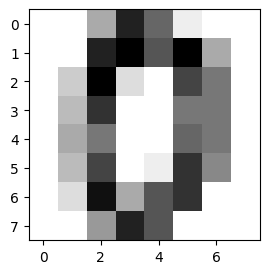

In [31]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(1, figsize=(3, 3))
plt.imshow(digits.images[0], cmap=plt.cm.gray_r, interpolation='nearest')
plt.show()

## Un ejemplo con SVM.

Con este conjunto de datos, vamos a utilizar el clasificador SVM (*Support Vector Machine*). Utilizaremos la mitad de los ejemplos para entrenar y la otra mitad para realizar el test.

Primero importamos las librerías necesarias y mostramos las 6 primeras imágenes de todo el conjunto de entrenamiento.

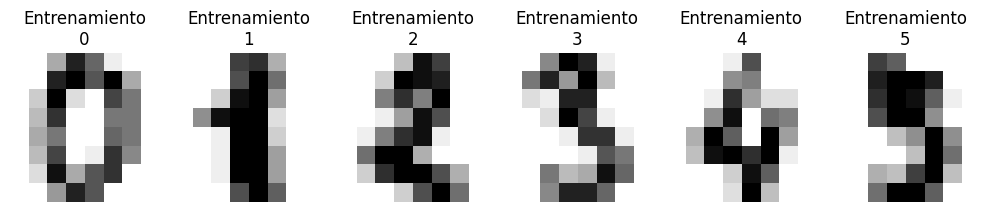

In [32]:
%matplotlib inline

import matplotlib.pyplot as plt
from sklearn import svm, metrics #SVM y funciones para las métricas

#Mostrar las 6 primeras imágenes
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(10,4))
for index, ax in enumerate(axes):
    image = digits.images[index]
    label = digits.target[index]
    ax.axis('off')
    ax.set_title('Entrenamiento\n{}'.format(label))
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    
fig.tight_layout()

A continuación entrenamos con la mitad de los ejemplos:

In [33]:
# Creamos el clasificador
cls = svm.SVC(gamma=0.001)

# Entrenamos con la mitad de los ejemplos
n_samples = len(digits.data)
train = digits.data[:n_samples // 2]
classes = digits.target[:n_samples // 2]
cls.fit(train, classes)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.001
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Por último utilizamos la otra mitad de los ejemplos para la predicción y calculamos algunas métricas de dicha predicción, como por ejemplo: precisión, cobertura, f1,...

In [34]:
expected = digits.target[n_samples // 2:]
predicted = cls.predict(digits.data[n_samples // 2:])

print("Informe del clasificador {}:".format(cls))
print("MÉTRICAS:\n{}".format(metrics.classification_report(expected, predicted)))
print("Matriz de confusión:\n{}".format(metrics.confusion_matrix(expected, predicted)))

Informe del clasificador SVC(gamma=0.001):
MÉTRICAS:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        88
           1       0.99      0.97      0.98        91
           2       0.99      0.99      0.99        86
           3       0.98      0.87      0.92        91
           4       0.99      0.96      0.97        92
           5       0.95      0.97      0.96        91
           6       0.99      0.99      0.99        91
           7       0.96      0.99      0.97        89
           8       0.94      1.00      0.97        88
           9       0.93      0.98      0.95        92

    accuracy                           0.97       899
   macro avg       0.97      0.97      0.97       899
weighted avg       0.97      0.97      0.97       899

Matriz de confusión:
[[87  0  0  0  1  0  0  0  0  0]
 [ 0 88  1  0  0  0  0  0  1  1]
 [ 0  0 85  1  0  0  0  0  0  0]
 [ 0  0  0 79  0  3  0  4  5  0]
 [ 0  0  0  0 88  0  0  0  0  4]
 [

A continuación mostramos algunos ejemplos clasificados:

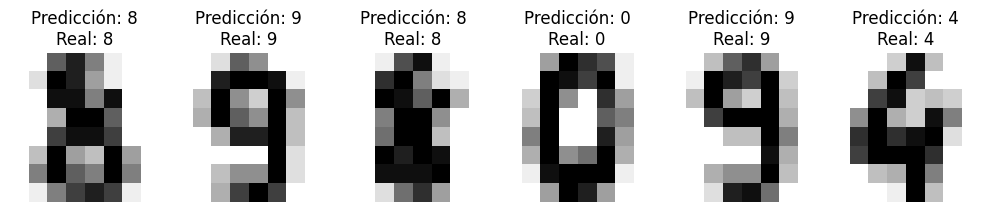

In [35]:
#Mostrar las 6 últimas imágenes y sus predicciones
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(10,4))
for index, ax in enumerate(axes):
    image = digits.images[-index-1]
    prediction = predicted[-index-1]
    label=expected[-index-1]
    ax.axis('off')
    ax.set_title('Predicción: {}\nReal: {}'.format(prediction,label))
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    
fig.tight_layout()


<img src="img/ejercicio2.png" style="float: left">

**Ejercicio**: Por defecto SVM utiliza el algoritmo RBF (*Radial Basis Function*), sin embargo, a la hora de crear el clasificador podemos utilizar el parámetro `kernel` para indicar otros algoritmos ('linear', 'poly', 'sigmoid', 'precomputed', ...)
Une todos los trozos de código Python de este ejemplo de clasificación y cambia el algoritmo que utiliza SVM para comprobar si hay diferencias.


In [36]:
from sklearn import svm

# Linear
cls = svm.SVC(kernel='linear')
cls.fit(train, classes)

# Polynomial
cls = svm.SVC(kernel='poly', degree=3)
cls.fit(train, classes)

# Sigmoid
cls = svm.SVC(kernel='sigmoid')
cls.fit(train, classes)

predicted = cls.predict(digits.data[n_samples // 2:])

## Persistencia del modelo.

Cuando se entrena un clasificador (o cualquier algoritmo de aprendizaje automático) se dice que se ha obtenido un modelo. Este modelo puede ser almacenado de forma persistente para, posteriormente ser cargado siempre que nos haga falta.

Para realizar esta persistencia podemos utilizar la librería `joblib` que incorpora `scikit-learn`:

In [37]:
from sklearn import svm, datasets
# from sklearn.externals import joblib
import joblib
clf = svm.SVC()
iris = datasets.load_iris()
X, y = iris.data, iris.target
clf.fit(X, y)  
joblib.dump(clf, 'modelo.pkl')

['modelo.pkl']

Para cargarlo, tan solo hace falta utilizar el método `load`:

In [38]:
clf2 = joblib.load('modelo.pkl')
print('Predicción: ',clf2.predict(X[0:1]))
print('Clase real: ',y[0])

Predicción:  [0]
Clase real:  0


## Validación del modelo

Una de las partes mas importantes del aprendizaje automático es la validación del modelo, es decir, como de bien se ajusta el modelo al conjunto de datos dado. Pero existen algunas trampas con las que hay que tener cuidado.

Volvamos al ejemplo de los dígitos.

In [39]:
from sklearn.datasets import load_digits
import numpy as np
digits = load_digits()
X = digits.data
y = digits.target

Utilicemos esta vez un clasificador de K-vecinos (*KNeighbors*):

In [40]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Ahora usemos el clasificador para predecir los números.

In [41]:
y_pred = knn.predict(X)

Finalmente, comprobemos como de buena es la predicción:

In [42]:
print("{0} / {1} correct".format(np.sum(y == y_pred), len(y)))

1797 / 1797 correct


El resultado es un clasificador *perfecto*. Sin embargo, hay un problema: **la validación no es correcta**.

## Conjuntos de validación

Para validar un clasificador no se pueden utilizar el mismo conjunto de entrenamiento. La mejor manera de validar el modelo es utilizar un conjunto de test que no esté incluido en el de entrenamiento.

La librería scikit-learn tiene utilizadas para crear conjuntos de entrenamiento y de test:

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)
X_train.shape, X_test.shape

((1347, 64), (450, 64))

Ahora tenemos un conjunto de entrenamiento y otro de test seleccionados aleatoreamente del conjunto global. Por lo tanto, podemos realizar el entrenamiento y el test con dichos subconjuntos independientes:

In [44]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("{0} / {1} correct".format(np.sum(y_test == y_pred), len(y_test)))

441 / 450 correct


Esta métrica nos da un valor estimado mas real de como de bien funciona nuestro modelo. La métrica utilizada se llama **precisión** (*accuracy*) y scikit-learn también tiene rutinas para calcularla directamente:

In [45]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.98

También se puede obtener directamente del modelo utilizando el método ``score``:

In [46]:
knn.score(X_test, y_test)

0.98

Ahora podemos utilizar distintos parámetros para el clasificador KNN y obtener un valor de validación. Por lo tanto, vamos a probar con distintos números de vecinos:

In [47]:
for n_neighbors in [1, 5, 10, 20, 30]:
    knn = KNeighborsClassifier(n_neighbors)
    knn.fit(X_train, y_train)
    print(n_neighbors, knn.score(X_test, y_test))

1 0.98
5 0.98
10 0.9733333333333334
20 0.9688888888888889
30 0.9622222222222222


En este caso en particular, cuantos menos vecinos tengamos mejores resultados obtendremos.

<img src="img/ejercicio2.png" style="float: left">

**Ejercicio**: Busca en la ayuda de `train_test_split` y genera dos particiones distintas: una con el 70% para entrenamiento y el 30% para test, y otra con 20 ejemplos para test y el resto para entrenamiento.


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

print("Accuracy:", knn.score(X_test, y_test))

Accuracy: 0.9888888888888889


## Validación cruzada

Un problema con los conjuntos de validación consiste en la pérdida de ejemplos, es decir, el conjunto de entrenamiento puede quedarse sin ejemplos suficientes de una o varias clases. Una solución sería crear un **validación cruzada** (*2-fold cross-validation*), creando dos conjuntos de ejemplos del mismo tamaño, y entrenando/validando dos veces:

In [49]:
X1, X2, y1, y2 = train_test_split(X, y, test_size=0.5, random_state=0)
X1.shape, X2.shape

((898, 64), (899, 64))

In [50]:
print(KNeighborsClassifier(1).fit(X2, y2).score(X1, y1))
print(KNeighborsClassifier(1).fit(X1, y1).score(X2, y2))

0.9832962138084632
0.982202447163515


### K-fold Cross-Validation

Scikit-learn nos permite realizar la validación cruzada, indicando incluso el número de subconjuntos que queremos generar. A esto se le denomina *$K$-fold cross-validation* y consiste en realizar $K$ particiones utilizando, cada vez, 1 partición de test y el resto para entrenamiento. Por lo tanto, se realizan $K$ validaciones:

In [51]:
from sklearn.model_selection import cross_val_score
cval = cross_val_score(KNeighborsClassifier(1), X, y, cv=10) #cv es el numero de particiones
cval

array([0.93333333, 0.99444444, 0.97222222, 0.97222222, 0.96666667,
       0.98333333, 0.99444444, 0.98882682, 0.97765363, 0.96648045])

La precisión media sería:

In [52]:
cval.mean()

np.float64(0.9749627560521414)

Esto nos da una mejor idea de como funciona nuestro modelo.

<div class="alert alert-success">
    <b>Ejercicio</b>: ¿Existe algún parámetro en `cross_val_score` que me permita utilizar mas de una CPU?
</div>

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    KNeighborsClassifier(1),
    X, y,
    cv=10,
    n_jobs=-1
)

print(scores)
print("Media:", scores.mean())



[0.93333333 0.99444444 0.97222222 0.97222222 0.96666667 0.98333333
 0.99444444 0.98882682 0.97765363 0.96648045]
Media: 0.9749627560521414


TypeError: missing a required argument: 'X'

<img src="img/ejercicio2.png" style="float: left">

**Ejercicio**: Existe otro método de validación denominado **uno-contra-todos** (*leave-one-out*) donde se utiliza todos los ejemplos menos uno para entrenar, y el que se queda fuera se utiliza para test. Busca en la ayuda el método para realizar esta validación y escribe el código para validar el clasificador KNN.

In [56]:
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score

loo = LeaveOneOut()

scores = cross_val_score(
    KNeighborsClassifier(1),
    X, y,
    cv=loo
)

print("Media:", scores.mean())

Media: 0.988313856427379


## Referencias para ampliar.

* [Scikit-learn](http://scikit-learn.org/stable/index.html)
* [Curso de Kevin Markham](https://github.com/justmarkham/scikit-learn-videos)